In [14]:
# import metric

In [15]:
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = "test2.png"
output_path = "output.svg"
img = PILImage.open(input_path)

In [ ]:

import re

def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "".join(polygons)
        + '</g></svg>'
    )

    return new_svg


def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code




def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    layer_difference = 10  # initial value
    max_svg_length = 9996  # target length limit

    # Define injection to prevent OCR hallucination
    injection = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white" fill="none"/>'
    injection_length = len(injection)

    while True:
        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=3,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=10,       # remove subtle corners
            length_threshold=10,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=10,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            continue  # go back to start of while loop

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length: # acount for injection
            break
        else:
            layer_difference += 10

    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length
    # svg_code = scale_svg_to_384(svg_code, size) # this adds roughly 30 bytes

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")
      

    return svg_code

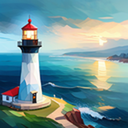

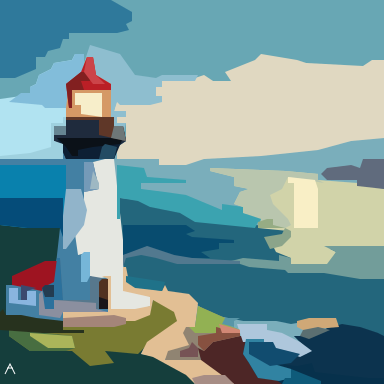

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 128,0 128,128 0,128" fill="#7AAEBB"/><polygon points="0,0 128,0 128,20 121,23 102,22 90,19 86,20 76,25 79,28 71,28 66,26 62,27 54,27 54,29 52,29 52,32 54,32 54,34 50,35 40,35 39,34 38,37 42,37 42,39 39,39 39,41 42,41 42,47 39,49 38,53 31,54 33,63 29,64 29,73 26,78 26,85 30,84 30,92 36,93 36,104 21,104 21,106 42,105 45,106 50,104 51,100 56,102 60,105 58,109 48,116 47,118 53,119 63,125 65,128 0,128" fill="#68A7B4"/><polygon points="40,66 49,67 52,69 60,70 65,73 85,75 96,76 97,79 92,83 97,86 97,88 109,88 112,84 108,82 128,82 128,128 78,128 67,120 65,114 69,116 71,113 81,112 82,113 91,114 92,116 102,118 103,117 98,112 103,112 110,109 113,109 112,107 103,107 97,108 92,107 81,107 71,105 63,100 63,98 59,99 54,97 45,96 42,94 40,80" fill="#23667C"/><polygon points="22,39 38,39 38,42 41,42 42,47 39,49 38,53 31,54 33,63 29,64 29,73 26,78 26,85 30,84 30,92 36,93 36,104 21,104 21,106 42,105 45,106 50,

In [17]:
svg_code = bitmap_to_svg_layered(img, input_path, output_path)
# Show the original PNG (resized)
display(Image(filename=input_path))

# Show the SVG result
display(SVG(svg_code))

# Print raw SVG XML code and its length
print(svg_code)
print(f'{len(svg_code)=}')
print(f'{len(svg_code.encode('utf-8'))=}')
print(len(svg_code.splitlines()))

In [18]:

import kaggle_evaluation
from kaggle_evaluation.svg_constraints import SVGConstraints

constraints = SVGConstraints()
constraints.validate_svg(svg_code)  # your svg_code here

In [19]:
# import metric


In [20]:
# from PIL import Image as PILImage
# input_path = "bucket-8_2.jpg"
# img = PILImage.open(input_path)

# image_processor = metric.ImageProcessor(img, seed=42).apply()
# image = image_processor.image.copy()
# aesthetic_score = metric.aesthetic_evaluator.score(image)
# print(f"Aesthetic score: {aesthetic_score}")